<a href="https://colab.research.google.com/github/JPacoch/post-glacial-ds/blob/main/testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio
!pip install geopandas
!pip install keras-spatial

In [ ]:
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dem = rasterio.open('/content/drive/My Drive/mag/DEM.tif')

In [ ]:
def parse_image(img_path: str) -> dict:
    
    src = rasterio.open(img_path)
    image_numpy = src.read()
    image = tf.convert_to_tensor(image_numpy, dtype=tf.float32)

    return {'image': image}

In [ ]:

num_bands = dem.count
print('Number of bands in image: {n}\n'.format(n=num_bands))

rows, cols = dem.shape
print('Image size is: {r} rows x {c} columns\n'.format(r=rows, c=cols))

driver = dem.driver
print('Raster driver: {d}\n'.format(d=driver))

proj = dem.crs
print('Image projection:')
print(proj)


Number of bands in image: 1

Image size is: 24064 rows x 27073 columns

Raster driver: GTiff

Image projection:
ESRI:102173


In [ ]:
landsat_image = dem.read()
landsat_image.shape

(1, 24064, 27073)

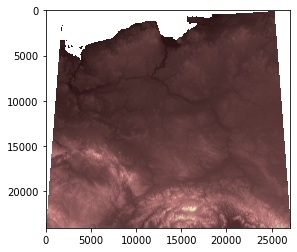

In [ ]:
plt.imshow(dem.read(1), cmap='pink')

In [ ]:
cat = rasterio.open('/content/drive/My Drive/mag/geomorph_Poland_smooth.tif')

In [ ]:
np.unique(cat.read(1))
masking_vals = [1,2,3,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,255]

In [ ]:
masked = np.ma.masked_equal(cat.read(1), 4)